<a href="https://colab.research.google.com/github/yashnayan8795/DeepLearningLabSession/blob/main/CNN_MNIST_DATASET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolution Neural Network

## Deep Learning Lab Session 03

Yash Nayan 22BDS0274

Problem Statement:
Write a Python program using TensorFlow/Keras to train a Convolutional Neural Network (CNN) for classifying handwritten digits from the MNIST dataset.
The program should include:

Data preprocessing

Model architecture

Training

Evaluation

Visualization of results

In [30]:
# MNIST CNN
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [31]:
tf.random.set_seed(42)
np.random.seed(42)

In [32]:
# 1) Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [33]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [34]:
# 2) Preprocess
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32")  / 255.0

In [35]:
X_train = np.expand_dims(X_train, axis=-1)
X_test  = np.expand_dims(X_test, axis=-1)

In [36]:
num_classes = 10
y_train_oh = to_categorical(y_train, num_classes)
y_test_oh  = to_categorical(y_test, num_classes)

In [37]:
# 3) Build model
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),


    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),

    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),

    layers.Flatten(),
    layers.Dropout(0.25),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

In [38]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# 4) Compile --------------------------------------------------
# Categorical crossentropy for multi-class; Adam is a good default optimizer.
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [40]:
history = model.fit(
    X_train, y_train_oh,epochs=8,batch_size=128,validation_split=0.1,verbose=1
)

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8406 - loss: 0.5339 - val_accuracy: 0.9825 - val_loss: 0.0628
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9762 - loss: 0.0758 - val_accuracy: 0.9877 - val_loss: 0.0437
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9839 - loss: 0.0498 - val_accuracy: 0.9893 - val_loss: 0.0357
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9881 - loss: 0.0380 - val_accuracy: 0.9908 - val_loss: 0.0336
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9895 - loss: 0.0326 - val_accuracy: 0.9902 - val_loss: 0.0346
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9920 - loss: 0.0249 - val_accuracy: 0.9907 - val_loss: 0.0324
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9929 - loss: 0.0213 - val_accuracy: 0.9910 - val_loss: 0.0320
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9921 - loss: 0.0220 - val_accuracy: 0.9902 -

In [41]:
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")


Test accuracy: 0.9914 | Test loss: 0.0290


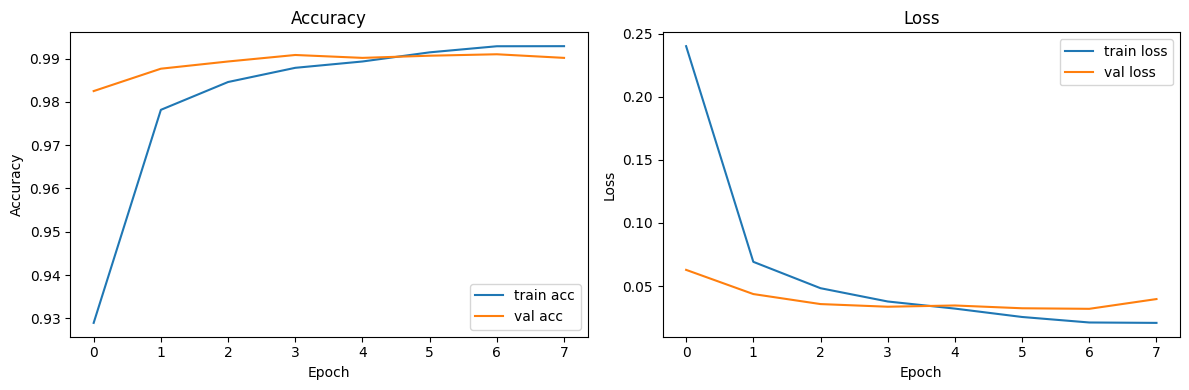

In [42]:
# 7) Visualize learning curves -------------------------------
plt.figure(figsize=(12,4))
# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.title("Accuracy")
plt.xlabel("Epoch");
plt.ylabel("Accuracy");
plt.legend()
# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Loss")
plt.xlabel("Epoch");
plt.ylabel("Loss");
plt.legend()
plt.tight_layout()
plt.show()


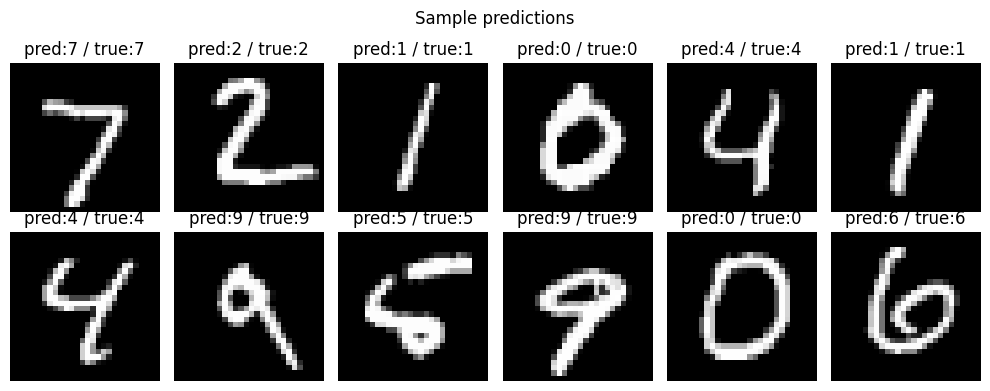

In [43]:
# 8) Show a few predictions
probs = model.predict(X_test[:12], verbose=0)
preds = probs.argmax(axis=1)

plt.figure(figsize=(10,4))
for i in range(12):
    plt.subplot(2,6,i+1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.title(f"pred:{preds[i]} / true:{y_test[i]}")
    plt.axis("off")
plt.suptitle("Sample predictions")
plt.tight_layout()
plt.show()